# Credit Card Transactions — Exploratory Data Analysis
**Author:** Rose Fidalgo Amorim  
**Dataset:** 50,000 credit card transactions (sample from 1.85M rows)  
**Tools:** Python · Pandas · Matplotlib · Seaborn  
## Objective
Analyse consumer spending behaviour across merchant categories, demographics and time patterns to generate business insights relevant to the financial services industry.


## 1- Data Loading & Exploration

In [26]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (10, 5) 

df = pd.read_csv("credit_card_transactions.csv")

df = df.sample(50000, random_state=42).reset_index(drop=True)
df = df.drop(columns=['Unnamed: 0'])

print("Shape :", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape : (50000, 23)

Columns:
['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'merch_zipcode']


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,Spring Church,...,-79.4545,972,Public relations account executive,1997-10-23,fff87d4340ef756a592eac652493cf6b,1362841766,40.420453,-78.865012,0,15909.0
1,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,Sixes,...,-124.4409,217,Retail merchandiser,1928-10-01,d0ad335af432f35578eea01d639b3621,1345650541,42.758860,-123.636337,0,NaN
2,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,Keisterville,...,-79.7853,184,Systems developer,1945-11-04,87f26e3ea33f4ff4c7a8bad2c7f48686,1330824856,40.475159,-78.898190,0,15961.0
3,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,Farmington,...,-77.3083,10717,Cytogeneticist,1952-10-13,9c34015321c0fa2ae6fd20f9359d1d3e,1371413078,43.767506,-76.542384,0,NaN
4,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,Lagrange,...,-104.1974,635,Product/process development scientist,1973-07-13,198437c05676f485e9be04449c664475,1336974888,41.040392,-104.092324,0,82082.0


We want to find the number of missing values per columns and the number of duplicate

In [27]:
print("Missing values per columns:")
valeurs_nulles = df.isnull().sum()[df.isnull().sum()>0]
print(valeurs_nulles)
print("Number of duplicates :", df.duplicated().sum())

Missing values per columns:
merch_zipcode    7533
dtype: int64
Number of duplicates : 0


## 2-  Data Cleaning

In [28]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time']) #convert to datetime
df['hour']=df['trans_date_trans_time'].dt.hour #extract hour
df['day_of_week']=df['trans_date_trans_time'].dt.day_name() #extract day name
print(df[['trans_date_trans_time','hour','day_of_week']].head())

  trans_date_trans_time  hour day_of_week
0   2020-03-09 15:09:26    15      Monday
1   2019-08-22 15:49:01    15    Thursday
2   2019-03-04 01:34:16     1      Monday
3   2020-06-16 20:04:38    20     Tuesday
4   2019-05-14 05:54:48     5     Tuesday


### Data Quality
The dataset contains no duplicate transactions. Only `merch_zipcode` has missing values (7,533 out of 50,000 rows), which will not affect our analysis since this column is not used.

## 3-Business KPIs

In [29]:
print("=" * 40)
print("BUSINESS KPIs — OVERVIEW")
print("=" * 40)
print(f"Total transactions   : {len(df):,}")
print(f"Total amount         : ${df['amt'].sum():,.2f}")
print(f"Average amount       : ${df['amt'].mean():.2f}")
print(f"Median amount        : ${df['amt'].median():.2f}")
print(f"Unique customers     : {df['cc_num'].nunique():,}")
print(f"Unique merchants     : {df['merchant'].nunique():,}")
print(f"Date range           : {df['trans_date_trans_time'].min()} → {df['trans_date_trans_time'].max()}")

BUSINESS KPIs — OVERVIEW
Total transactions   : 50,000
Total amount         : $3,525,694.67
Average amount       : $70.51
Median amount        : $47.66
Unique customers     : 932
Unique merchants     : 693
Date range           : 2019-01-01 00:17:40 → 2020-06-21 12:13:36


These KPIs provide a global overview of customer activity before exploring spending patterns in more detail.

## 4- Merchant Risk Analysis : Volume vs. Fraud

To understand where fraudulent activity is concentrated, we analyze the top merchants by transaction value. We break this down into three views : **Global Volume**, **Legitimate Volume**, and **Fraudulent Volume**. This allows us to pinpoint which high-volume merchants are safe and which ones present a high risk of fraud.

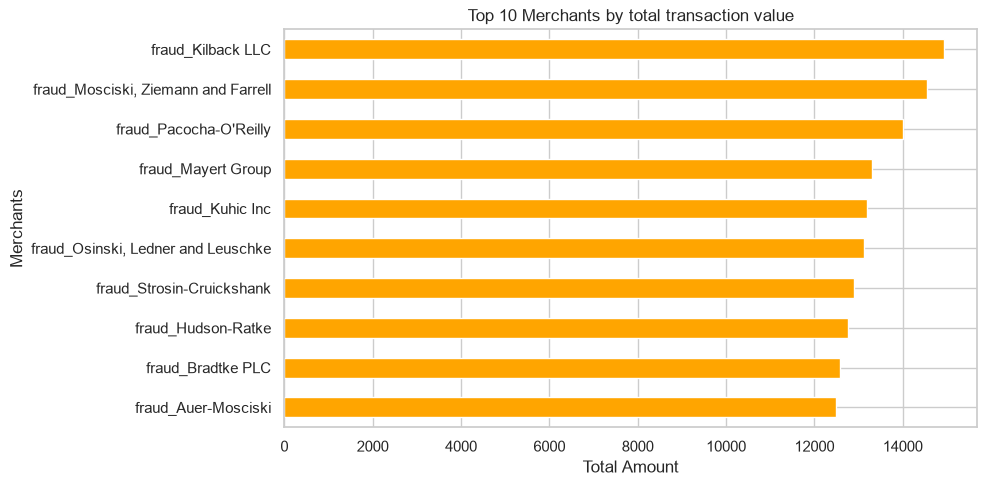

In [30]:
Top_10_merchants=df.groupby("merchant")["amt"].sum().sort_values(ascending=False).head(10)

Top_merchants = Top_10_merchants.sort_values(ascending=True)
plt.figure(figsize=(10,5))
Top_merchants.plot(kind="barh", color="orange", edgecolor="white")
plt.title("Top 10 Merchants by total transaction value")
plt.ylabel("Merchants")
plt.xlabel("Total Amount")

plt.tight_layout()
plt.show()

**Graph Interpretation & Analysis (Global Volume):**
* **Baseline Distribution:** This chart establishes our transaction baseline, showing the top 10 merchants driving the highest overall financial volume. Total amounts are high, ranging between $12,500 and $15,000 per merchant.
* **Key Observations:** `fraud_Kilback LLC` leads the ecosystem in overall transaction volume, followed closely by `fraud_Mosciski, Ziemann and Farrell` and `fraud_Pacocha-O'Reilly`. 

### Business Insight — Global Volume
The top 10 merchants by total transaction value drive amounts ranging from 
$12,500 to $15,000. At this stage, without fraud filtering, these merchants 
appear to be the primary volume drivers of the ecosystem. However, raw volume 
alone is not a reliable indicator of merchant health — fraud exposure must be 
assessed separately.

## Legitimate Volume vs. Strict Zero-Fraud Channels

To push our risk assessment further, we compare two distinct definitions of "safe" volume:
1. **Legitimate Volume:** Merchants sorted by their clean transactions (fraudulent transactions are simply deducted).
2. **Strict Zero-Fraud Merchants:** High-volume merchants that have strictly **never** encountered a single fraudulent transaction in this dataset.


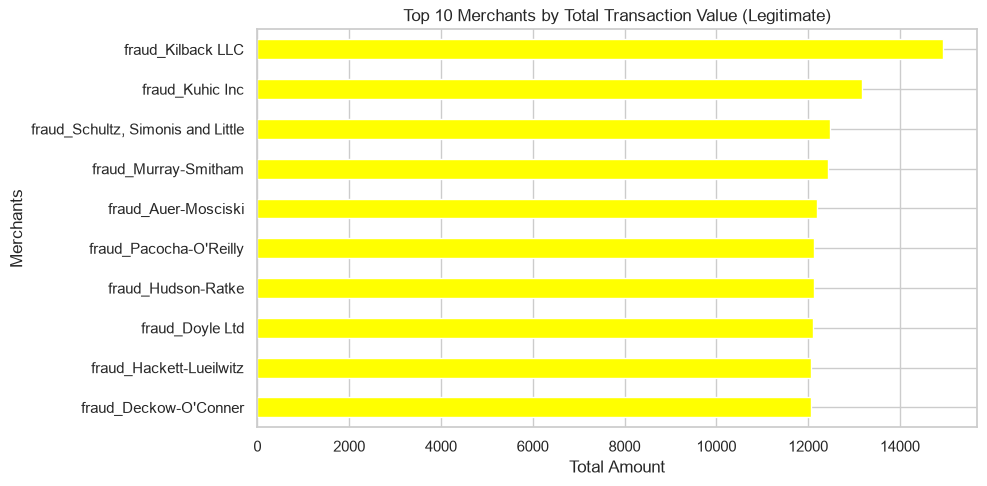

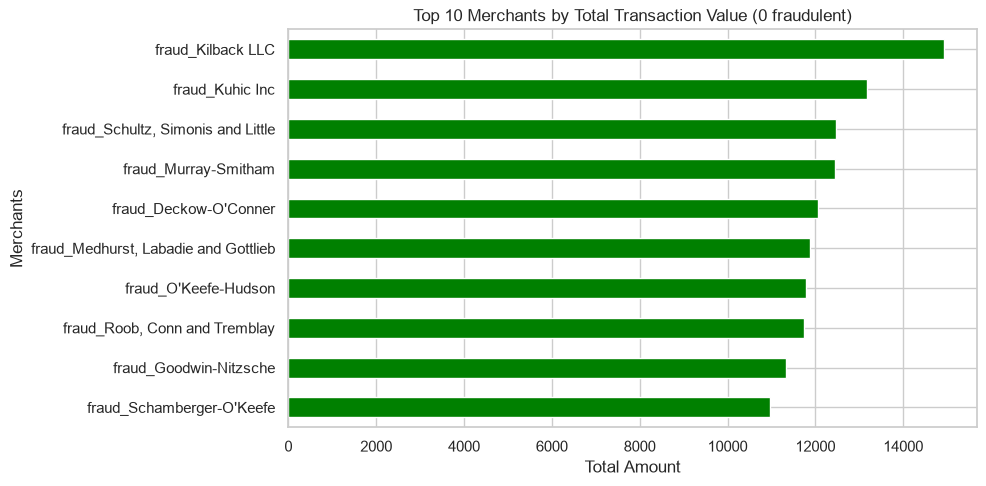

In [ ]:

df_legit = df[df["is_fraud"] == 0]
top_10_legit = (
    df_legit.groupby("merchant")["amt"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)


plt.figure(figsize=(10, 5))
top_10_legit.plot(kind="barh", color="yellow", edgecolor="white")
plt.title("Top 10 Merchants by Total Transaction Value (Legitimate)")
plt.ylabel("Merchants")
plt.xlabel("Total Amount")
plt.tight_layout()
plt.show()


merchants_with_fraud = df[df["is_fraud"] == 1]["merchant"].unique()
df_zero_fraud = df[~df["merchant"].isin(merchants_with_fraud)]

top_10_zero_fraud = (
    df_zero_fraud.groupby("merchant")["amt"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)
plt.figure(figsize=(10, 5))
top_10_zero_fraud.plot(kind="barh", color="green", edgecolor="white")
plt.title("Top 10 Merchants by Total Transaction Value (0 fraudulent)")
plt.ylabel("Merchants")
plt.xlabel("Total Amount")
plt.tight_layout()
plt.show()

**Graph Interpretation & Analysis (Legitimate Volume):**
* By isolating transactions where `is_fraud == 0`, we reveal the true financial health of our merchant network. `fraud_Kilback LLC` remains the undisputed leader, proving that its high volume is entirely genuine and safe. Indeed, fraud_Kilback LLC maintains an identical ranking in both the global and legitimate views, confirming that its entire transaction volume is fraud-free — making it the most reliable high-volume merchant in the dataset.

* **The Disappearance of High-Volume Giants:** In contrast to what was observed in the global view, total amounts are slightly lower, with most merchants ranging between $12,000 and $13,000. Actually, a critical anomaly occurs here. Multiple top-tier merchants from the global chart, specifically `fraud_Mosciski, Ziemann and Farrell`, `fraud_Pacocha-O'Reilly`, and `fraud_Mayert Group`have dropped out entirely off the Top 10 Legitimate ranking. 

* **Insight:** This sudden shift indicates that a substantial portion of their global volume was not legitimate. Conversely, trusted merchants like `fraud_Schultz, Simonis and Little` or `fraud_Murray-Smitham` climb into the top spots, proving they run highly secure operations with low fraud exposure.


**Graph Interpretation & Analysis (100% Safe Volume):**

Remarkably, the Top 10 zero-fraud merchants still achieve massive volumes, closely concentrated between **$11,000 and $15,000**.

* **Exceptional Operational Security:** The fact that merchants can process up to $15,000 in volume with a strict fraud count of zero indicates exceptional internal risk controls, robust 3D-Secure implementations, or a highly verified customer base.
* **"Green Channel" Candidates:** Merchants maintaining these high volumes while maintaining a flawless zero-fraud record are prime candidates for whitelisting or low-friction routing. They represent the lowest-risk merchants in our ecosystem.
* **Density & Stability :** Just like the previous metrics, the tight range ($11k - $15k) proves that our top clean merchants operate on a highly identical scale, making any sudden appearance of fraud an immediate red flag for our monitoring systems.

### Business Insight — Zero-Fraud Merchants
The top 10 strict zero-fraud merchants still achieve volumes between $11,000 
and $15,000 — comparable to the overall top merchants — while recording no 
fraudulent transactions whatsoever. This demonstrates that high volume and 
low fraud risk are not mutually exclusive.

These merchants are prime candidates for preferential treatment:
- **Whitelisting** : reduced friction in transaction approval flows
- **Partnership programmes** : cashback or reward schemes for customers 
  transacting with verified low-risk merchants
- **Fraud monitoring benchmarks** : their zero-fraud profiles can serve 
  as a baseline for anomaly detection across the broader merchant network

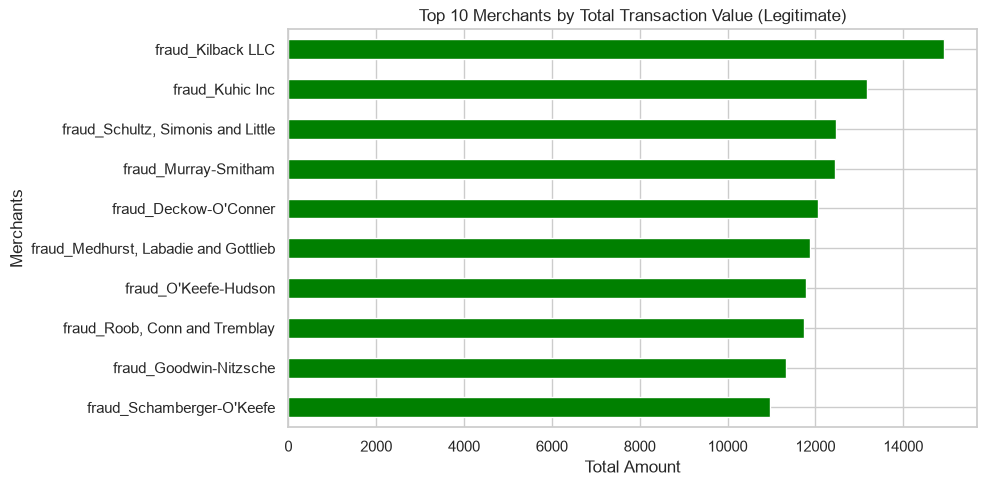

In [32]:
# 1. Identifier la liste des marchands qui ont AU MOINS une fraude
merchants_with_fraud = df[df["is_fraud"] == 1]["merchant"].unique()

# 2. Exclure complètement ces marchands du DataFrame
df_zero_fraud = df[~df["merchant"].isin(merchants_with_fraud)]

# 3. Faire le Top 10 sur ces marchands 100% cleans
top_10_zero_fraud = (
    df_zero_fraud.groupby("merchant")["amt"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)
plt.figure(figsize=(10, 5))
top_10_zero_fraud.plot(kind="barh", color="green", edgecolor="white")
plt.title("Top 10 Merchants by Total Transaction Value (Legitimate)")
plt.ylabel("Merchants")
plt.xlabel("Total Amount")
plt.tight_layout()
plt.show()


## 5- Spending Categories Analysis

**Which category occurs the most transactions and the highest amount ?**

category
gas_transport     5051
grocery_pos       4776
home              4755
shopping_pos      4532
kids_pets         4261
shopping_net      3803
entertainment     3681
food_dining       3621
personal_care     3400
health_fitness    3245
misc_pos          3073
misc_net          2358
grocery_net       1834
travel            1610
Name: count, dtype: int64


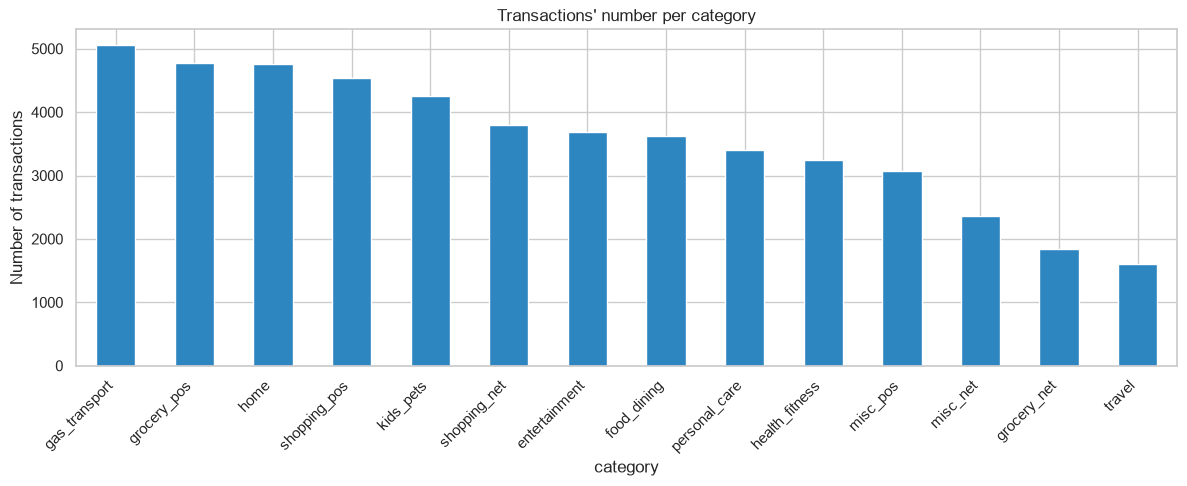

In [34]:
cat_counts=df['category'].value_counts()
print(cat_counts)

plt.figure(figsize=(12, 5)) #12 large 5 haut (alternative : petit = 8,4 grand= 15,8)
cat_counts.plot(kind='bar', color='#2E86C1', edgecolor='white') #edgecolor=contour des barres
#kind = type de graphique bar= barres verticales
#kind='barh'= barres horizontales (mieux quand les labels sont longs)
#kind='line'= courbe
#kind='pie'=camembert
#kind='hist'= histogramme
plt.title("Transactions' number per category")  # titre du graphique
plt.xlabel('category')  # légende axe X
plt.ylabel('Number of transactions')  # légende axe Y
plt.xticks(rotation=45, ha='right')
plt.tight_layout() #Ajuste automatiquement les marges pour que rien ne soit coupé
plt.show()

Here, we observe that categories with the expenditures the most frequent are the gas transport (5,051) and the groceries (4,776). We notice that the travel transactions occurs at the last position (1,610) beside the groceries on the net (1,834). The number of transactions in gas transport are approximatively 3 times more important than the travel's.

category
grocery_pos     118.358344
shopping_net     96.757754
travel           94.171720
Name: amt, dtype: float64


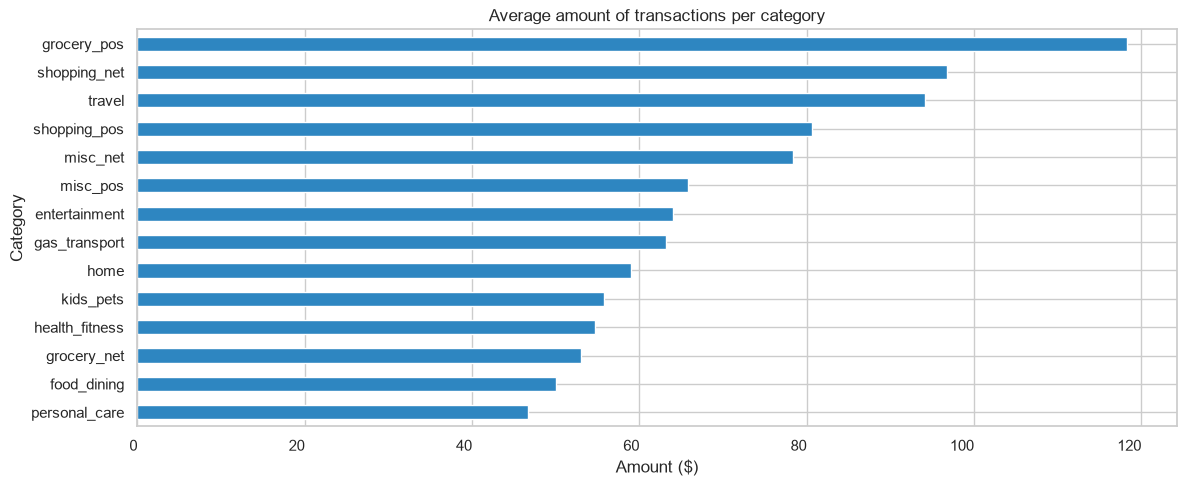

In [35]:
avg_by_cats = df.groupby('category')['amt'].mean()
avg_by_cats = avg_by_cats.sort_values(ascending=True)
print(avg_by_cats.sort_values(ascending=False).head(3))

plt.figure(figsize=(12, 5)) #12 large 5 haut (alternative : petit = 8,4 grand= 15,8)
avg_by_cats.plot(kind='barh', color='#2E86C1', edgecolor='white') #edgecolor=contour des barres
#kind = type de graphique bar= barres verticales
#kind='barh'= barres horizontales (mieux quand les labels sont longs)
#kind='line'= courbe
#kind='pie'=camembert
#kind='hist'= histogramme
plt.title("Average amount of transactions per category")  # titre du graphique
plt.xlabel('Amount ($)')  # légende axe X
plt.ylabel('Category')  # légende axe Y
plt.xticks(rotation=0, ha='right')
plt.tight_layout() #Ajuste automatiquement les marges pour que rien ne soit coupé
plt.show()



We notice that the travel category which has the lowest transactions frequency ranks in the top 3 for the average amount spent. Oddly, this category is not the first suggesting that it encompasses both small expenditures like bus tickets and large expenses such as flights or hotels.Therefore, the categories with the most transactions are not those with the highest average amount. However, a key point, the groceries represent the second highest number of transaction but also the highest average amount. That suggests regular habits like the monthly grocery shopping.

### Business Insight
These findings suggest two distinct business opportunities. First, grocery 
customers — frequent, high-spending, and predictable — are ideal candidates 
for loyalty programmes and cashback rewards. Second, travel transactions, 
despite lower frequency, carry high individual value and a mixed risk profile 
(from low-cost transport to premium bookings), making them a priority for 
both fraud monitoring and premium customer targeting.

## 6- Demographics analysis 

**Do the spending vary by the gender and the profession ?**

        Average amount ($)  Nb transactions  Total spent ($)
gender                                                      
F                    70.26            27540       1935045.85
M                    70.82            22460       1590648.82


C:\Users\rosea\AppData\Local\Temp\ipykernel_5936\3545445060.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='amt', palette=['#2E86C1', 'pink'])


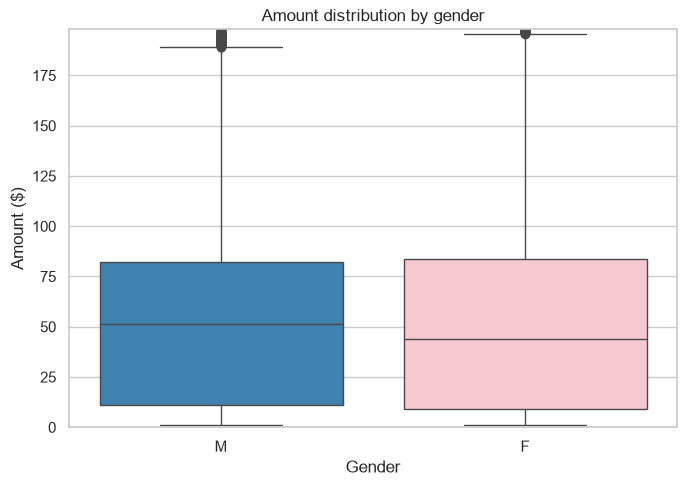

In [36]:
avg_by_gender = df.groupby('gender')['amt'].agg(['mean', 'count', 'sum']).round(2)
avg_by_gender.columns = ['Average amount ($)', 'Nb transactions', 'Total spent ($)']
print(avg_by_gender)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='gender', y='amt', palette=['#2E86C1', 'pink'])
plt.title("Amount distribution by gender")
plt.xlabel("Gender")
plt.ylabel("Amount ($)")
plt.ylim(0, df['amt'].quantile(0.95))  # retire les valeurs extrêmes pour la lisibilité
plt.tight_layout()
plt.show()

Contrary to what we might expect, we note that there is not a huge difference between the men's and women's average spending. They are both close to 70$ (70.26$ for the women and 70.82$ for the men).
 Nevertheless, we see that the men's median is higher than the women's, approximatively 51-52$ for the men against approximatively 45$ for the women.
 Which suggests that the women's expenditures are more steady while men tend to make occasional higher-value purchases that pull the median up. Moreover, women made more transactions overall (27,540 against 22,460), confirming that they transact more frequently but at lower individual amounts..

### Business Insight
Gender alone has limited explanatory power for transaction value — average 
amounts are nearly identical across both groups. More granular variables 
such as income level, age bracket or geographic location would likely provide 
stronger customer segmentation signals and enable more targeted product 
recommendations.

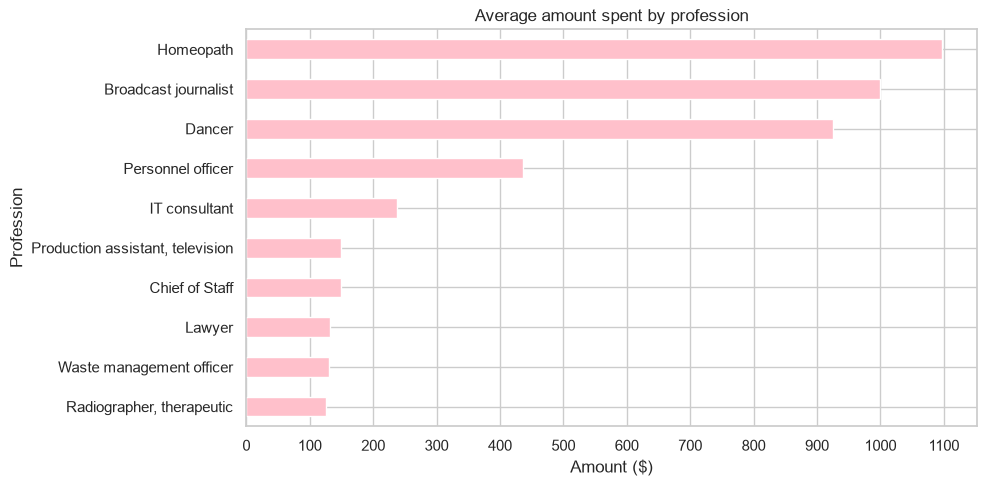

In [37]:
TOP_job = df.groupby('job')['amt'].mean().sort_values(ascending=False).head(10)
TOP10_job=TOP_job.sort_values(ascending=True)
plt.figure(figsize=(10, 5))
TOP10_job.plot(kind='barh', color='pink', edgecolor='white')
plt.title("Average amount spent by profession")
plt.xlabel("Amount ($)")
plt.ylabel("Profession")
plt.xticks(range(0,1200,100))

plt.tight_layout()
plt.show()

We can note that the top 10 of the highest amount spent by profession is very irregular. Indeed, the top 3 : Homeopath (the highest amount spent : aproximatively 1,100$), Broadcast journalist (1,000$) and the Dancer (930$) do not fall below 900$. However, the 4th, the personnel officer spend approximatively 440$. We can observe a huge difference between the top 3 and the others suggesting significant difference in income and consequently in spending habits. For instance, the highest-spending profession spends approximately 10 times more than the lowest (110$).

### Business Insight
Some professions show very high average spending. However, these results 
should be interpreted with caution — rare professions may be represented 
by only a few transactions in the sample, making averages statistically 
unreliable. Income level and account type would be stronger segmentation 
variables for product targeting.

## 7- Time analysis

**At which moment of the day and the week the spending are the most frequent ?**

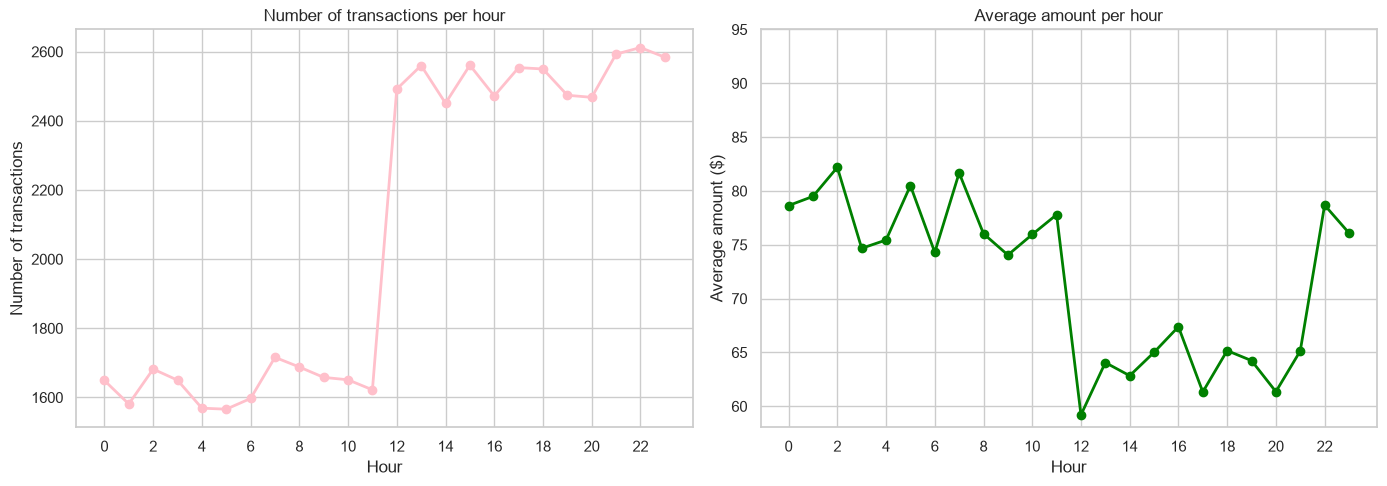

In [ ]:
transactions_per_hour = df.groupby('hour')['amt'].agg(['count','mean'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 — gauche
transactions_per_hour['count'].plot(ax=ax1, kind='line', marker='o', color='pink', linewidth=2)
ax1.set_title('Number of transactions per hour')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Number of transactions')
ax1.set_xticks(range(0, 24, 2))

# Graphique 2 — droite
transactions_per_hour['mean'].plot(ax=ax2, kind='line', marker='o', color='green', linewidth=2)
ax2.set_title('Average amount per hour')
ax2.set_xlabel('Hour')
ax2.set_ylabel('Average amount ($)')
ax2.set_xticks(range(0, 24, 2))
ax2.set_yticks(range(60, 100, 5))

plt.tight_layout()
plt.show()

We can see that between midnight and 11 AM there are few transactions, no hour exceeds 1,700 transactions and a local peak at 7 AM. However, at 12PM, activity rises and reaches 2,500 transactions.
 The daily peak occurs at 10PM with approximately 2,600 transactions. Moreover, in the afternoon, transaction volumes never fall below 2,450 transactions per hour, confirming that this is the busiest period of the day alongside the evening peak


Like we have seen for the categories, the hours which have the highest number of transaction are not those with the highest average amounts. In fact, between 12 PM and 9 PM, when transactions volumes are at their peak, the transaction amounts are at their lowest, not exceeding 67$ reached at 4 PM. 
However, between 10 PM and 11 AM, when fewer transactions occur, average amounts never fall below 74$. The peak is reached at 2AM and 7 AM with 83$. This suggests that daytime transactions tend to be frequent but small (everyday purchases), while late-night and early-morning transactions are rarer but of higher value.

### Business Insight
Transaction volume peaks in the afternoon and evening, while average amounts are highest overnight (10 PM–11 AM). This overnight pattern — fewer but higher-value transactions — is consistent with travel or exceptional purchases and could be a useful signal for fraud detection models.

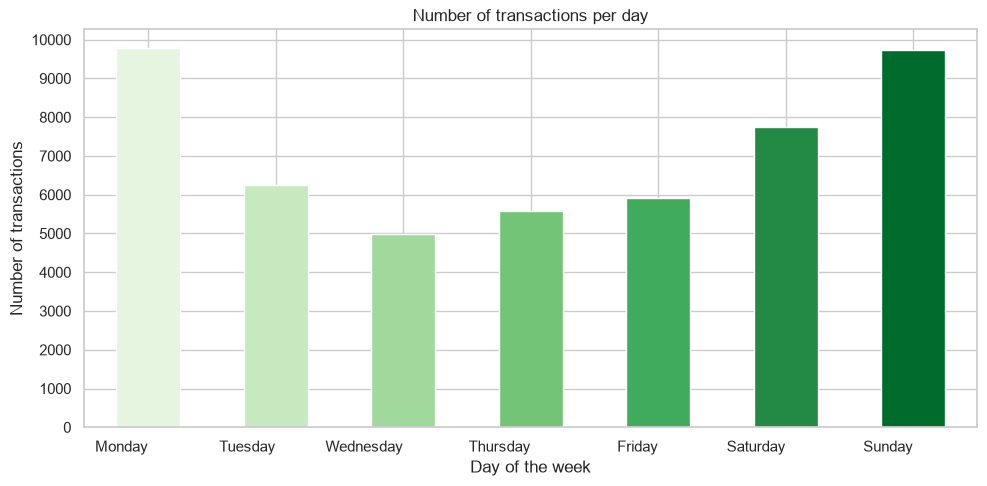

day_of_week
Monday       9774
Tuesday      6261
Wednesday    4990
Thursday     5582
Friday       5903
Saturday     7756
Sunday       9734
Name: amt, dtype: int64


In [ ]:
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
colors = sns.color_palette("Greens", 7)

transactions_per_day = df.groupby('day_of_week')['amt'].count().reindex(day_order)
plt.figure(figsize=(10, 5))
transactions_per_day.plot(kind='bar', color=colors, edgecolor='white')

plt.title('Number of transactions per day')
plt.xlabel('Day of the week')
plt.ylabel('Number of transactions')
plt.xticks(rotation=0, ha='right')
plt.yticks(range(0,11000,1000))
plt.tight_layout()
plt.show()
print(transactions_per_day)



The weekly peak is reached on Monday with 9,774 transactions, closely followed by Sunday with 9,734. 
These two days are by far the busiest of the week. Indeed, the remaining days do not exceed 7,756 reached on Saturday. Therefore, we can see that transaction volumes drop sharply mid-week, hitting a low of 4,990 on Wednesday before recovering on Saturday.

### Business Insight
The U-shaped weekly pattern (high on Monday and Sunday, low mid-week) suggests that customers tend to make larger shopping trips at the start and end of the week. This could inform the timing of promotional notifications or cashback offers.

## SUMMARY

This analysis of 50,000 real credit card transactions reveals several key patterns in consumer spending behaviour.

Spending frequency and spending value do not follow the same logic: the most transacted categories (grocery, gas) are not always those with the highest average amounts, and the busiest hours of the day (afternoon and evening) correspond to the lowest average transaction values. This inverse relationship is a consistent finding across both the category and temporal analyses.

Gender has no significant impact on overall spending patterns, though men show a slightly higher median transaction value. Profession, by contrast, shows wider variation — though results for rare professions should be interpreted with caution given small sample sizes.

Transaction volumes follow clear temporal patterns: average transaction amounts are highest during off-peak hours (10 PM–11 AM), while volume peaks on Mondays and Sundays. Mid-week (Wednesday) represents the quietest period of the week.

Finally, the merchant-level fraud analysis reveals that raw transaction volume is a misleading indicator of merchant health : several top merchants by global volume disappear entirely from the legitimate ranking, while a distinct group of high-volume, zero-fraud merchants emerges as the most reliable partners in the ecosystem, with direct implications for fraud monitoring, merchant risk scoring, and partnership programmes.

## Limitations

- This analysis is based on a sample of 50,000 transactions (2.7% of the full dataset); results are indicative rather than definitive.
- The analysis is descriptive and does not establish causal relationships.
- Profession-level results are sensitive to sample size for underrepresented categories and should be interpreted with caution.
- Key variables such as customer income, age and account type are unavailable, limiting deeper segmentation.
- Future work could include predictive modelling, customer lifetime value analysis, or fraud detection.

## Business Recommendations

Based on this analysis, several opportunities emerge:

- **Monitor overnight transactions** : high average values between 10 PM and 11 AM suggest a distinct spending profile worth flagging for fraud detection.
- **Design category-based offers** : grocery and travel categories show the highest average amounts and are strong candidates for cashback or reward programmes.
- **Rethink gender-based segmentation** : gender shows limited impact on spending; behavioural and temporal variables are more predictive.
- **Time marketing campaigns strategically** : Monday and Sunday see the highest activity; these are optimal days for push notifications and promotions.
- **Implement merchant-level fraud monitoring** : global volume rankings 
  alone are misleading: several top merchants by total volume disappear 
  from the legitimate ranking, revealing significant hidden fraud exposure. 
  A two-tier merchant scoring system (total volume + fraud rate) would 
  enable more accurate risk assessment and preferential routing for 
  verified zero-fraud partners.